In [2]:
import matplotlib.pyplot as plt
import numpy as np
from open_ephys.analysis import Session
import os
import re
from scipy.signal import butter, filtfilt, lfilter
from collections import defaultdict
import scipy.stats as statsz
import ipywidgets as widgets
from ipywidgets import Button, Output, VBox
from IPython.display import display

In [3]:
def scan_experiment_structure(session_dir, record_node_name="Record Node 111"):
    node_path = os.path.join(session_dir, record_node_name)

    if not os.path.exists(node_path):
        print(f"Record Node directory not found: {node_path}")
        return {}

    experiment_info = defaultdict(list)

    for item in sorted(os.listdir(node_path)):
        exp_path = os.path.join(node_path, item)
        if os.path.isdir(exp_path) and item.startswith("experiment"):
            recordings = [
                r for r in sorted(os.listdir(exp_path))
                if os.path.isdir(os.path.join(exp_path, r)) and r.startswith("recording")
            ]
            experiment_info[item] = recordings

    return experiment_info


In [4]:
# ==== Select record node ====
# w = 0 → Record Node 106
# w = 1 → Record Node 111
w = 0

#directory = "dEMG_TestN2025-12-19_12-06-47_001"
#directory = 'dEMGpilot2'
#directory = 'dEMGPr1_Test22026-03-05_18-22-35_001'
#directory = 'dEMGPr2_Test22026-03-05_18-49-34_002'
directory = 'dEMGPilot3-4-9-26'
session = Session(directory)
print("Session loaded successfully.\n")
print(session)


Session loaded successfully.


Open Ephys Recording Session Object
Directory: dEMGPilot3-4-9-26

<object>.recordnodes:
  Index 0: Record Node 101 (binary format)
  Index 1: Record Node 106 (binary format)



In [5]:
# === Flatten experiment-recording pairs to loop ===
#flat_recordings = []
#for exp_name, rec_list in structure.items():
#    for rec in rec_list:
#        flat_recordings.append((exp_name, rec))

In [6]:
record_node_name = "Record Node 106" if w == 0 else "Record Node 111"

structure = scan_experiment_structure(directory, record_node_name)
structure


defaultdict(list, {'experiment2': ['recording1']})

In [7]:
recording_index = 0   # choose which recording to load

try:
    recording = session.recordnodes[w].recordings[recording_index]
    print("Loaded:", recording)
except IndexError:
    print(f"Recording index {recording_index} not found.")



directory_str = recording.directory  # full directory path as a string

print("\n\n\n")

print(directory_str)


parts = directory_str.split(os.sep)

# Extract components based on Open Ephys folder structure
record_node_name = parts[-3]   # "Record Node 111"
experiment_name  = parts[-2]   # "experiment1"
recording_name   = parts[-1]   # "recording1"

print(record_node_name)
print(experiment_name)
print(recording_name)



Loaded: Open Ephys GUI Recording
ID: 0x1b917325fd0
Format: Binary
Directory: dEMGPilot3-4-9-26\Record Node 101\experiment2\recording1
Experiment Index: 0
Recording Index: 0




dEMGPilot3-4-9-26\Record Node 101\experiment2\recording1
Record Node 101
experiment2
recording1


In [8]:
continuous_list = recording.continuous

print(f"Number of continuous streams: {len(continuous_list)}")

stream = continuous_list[0]   # pick first continuous stream
print(stream)

metadata = stream.metadata
channel_names = metadata.channel_names
sample_rate = metadata.sample_rate
num_channels = metadata.num_channels
print("Sample rate:", metadata.sample_rate)
print("Num channels:", metadata.num_channels)
print("Channel names:", metadata.channel_names)


Number of continuous streams: 1
Continuous Data: Acquisition_Board-100.Rhythm Data/ (format='binary', mmap_mode=r)
├─── Samples: 4897763 samples x 9 channels
└─── ContinuousMetadata(source_node_id=100,
                   source_node_name='Acquisition Board',
                   stream_name='Rhythm Data',
                   sample_rate=5000.0,
                   num_channels=9,
                   channel_names=['CH1',
                                  'CH5',
                                  'CH7',
                                  'CH8',
                                  'CH10',
                                  'CH12',
                                  'ADC1',
                                  'ADC2',
                                  'ADC3'],
                   bit_volts=[0.1949999928474426,
                              0.1949999928474426,
                              0.1949999928474426,
                              0.1949999928474426,
                              0.19499999284744

In [9]:
# Load continuous data using global timestamps and data shape
timestamps = recording.continuous[0].timestamps
n_timestamps = timestamps.shape[0]
data = recording.continuous[0].get_samples(start_sample_index=0, end_sample_index=n_timestamps)
print("Data shape:", data.shape)

Data shape: (4897763, 9)


In [13]:
# ==== EMG Processing ====
emg1_raw = data[:, 4]
emg2_raw = data[:, 5]
differential = (emg2_raw - emg1_raw)
lowcut = 100
highcut = 1000

b, a = butter(2, np.array([lowcut, highcut])/(sample_rate/2), btype='bandpass')


#y = lfilter(b, a, x) # only filters in the forward direction

emg1 = lfilter(b, a, emg1_raw)
emg2 = lfilter(b, a, emg2_raw)
differential_filt = lfilter(b, a, differential)

In [14]:

#differential_filt = data[:,3]
differential_filt = lfilter(b, a, differential)
differential_abs = np.abs(differential_filt)
differential_emg = differential_abs

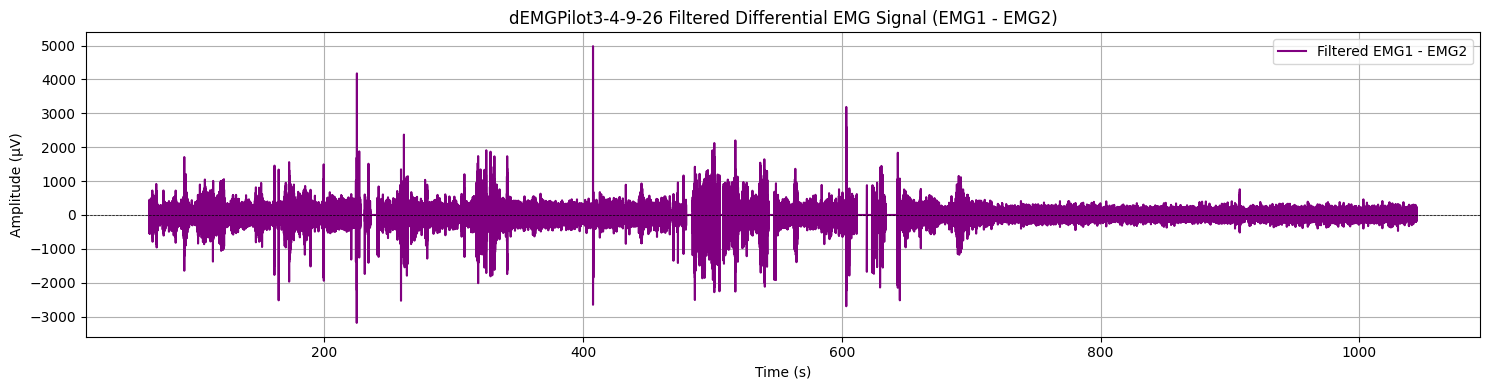

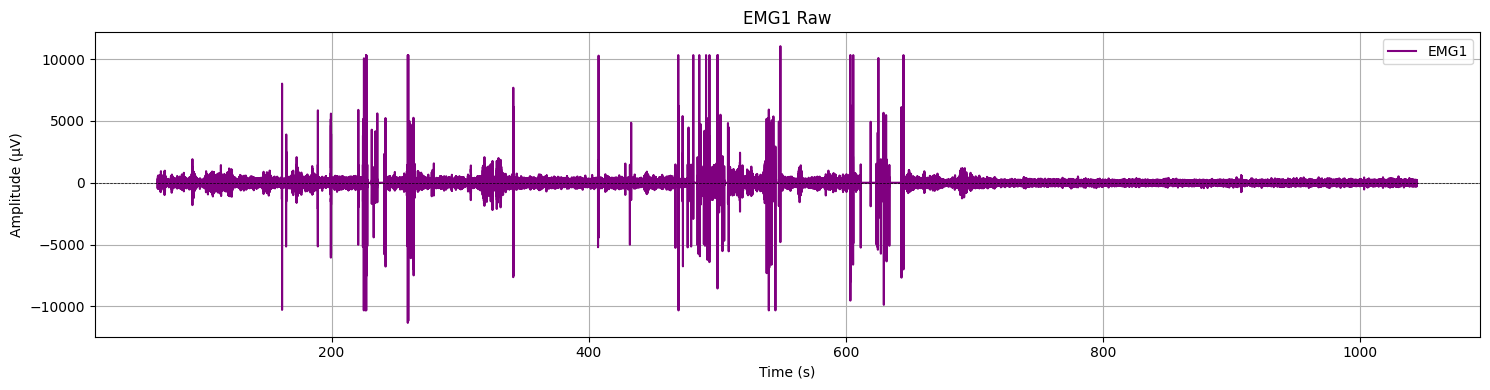

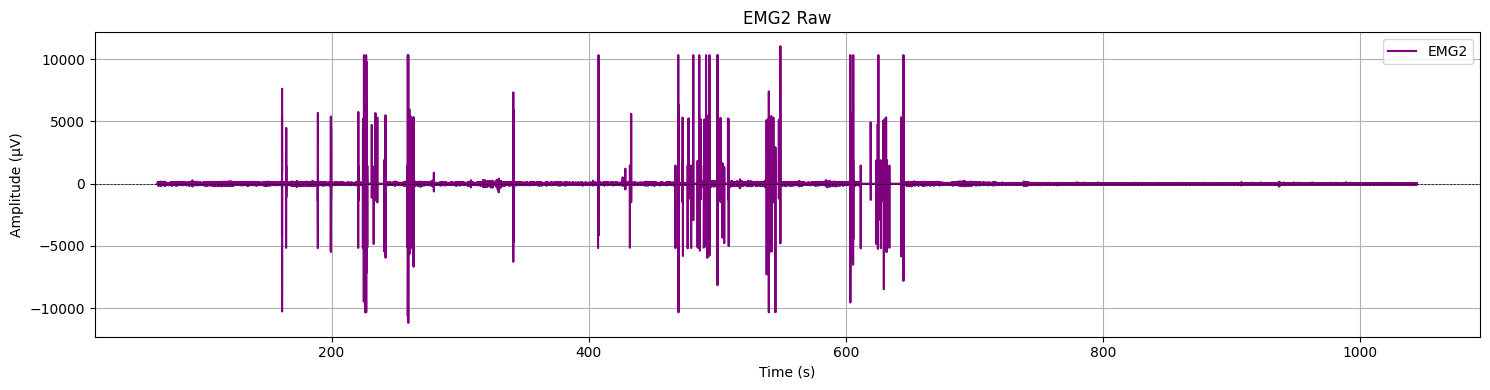

In [15]:
#differential_filt = data[:,3] #Only if online filtered, if not then comment out 

# ==== Full Trace Plot ====
plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_filt, label="Filtered EMG1 - EMG2", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
# plt.title(f"{directory}, {experiment_name}, {recording_name}, Filtered Differential EMG Signal (EMG1 - EMG2)")
plt.title(f"{directory} Filtered Differential EMG Signal (EMG1 - EMG2)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.grid(True)
plt.legend()
#plt.ylim(top=1000)
#plt.ylim(bottom=-1000)
plt.tight_layout()

plt.show()

# ==== Full Trace Plot ====
plt.figure(figsize=(15, 4))
plt.plot(timestamps, emg1, label="EMG1", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"EMG1 Raw")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.grid(True)
plt.legend()
#plt.ylim(top=1000)
#plt.ylim(bottom=-1000)
plt.tight_layout()

plt.show()

# ==== Full Trace Plot ====
plt.figure(figsize=(15, 4))
plt.plot(timestamps, emg2, label="EMG2", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"EMG2 Raw")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.grid(True)
plt.legend()
#plt.ylim(top=1000)
#plt.ylim(bottom=-1000)
plt.tight_layout()

plt.show()

In [ ]:
#differential_filt = data[:,3] #Only if online filtered, if not then comment out 

# Segment setup
total_time = timestamps[-1] - timestamps[0]
segment_duration = 10  # seconds
num_segments = int(np.ceil(total_time / segment_duration))
current_segment = 0

def plot_segment(segment_idx):
    start_time = timestamps[0] + segment_idx * segment_duration
    end_time = min(start_time + segment_duration, timestamps[-1])
    mask = (timestamps >= start_time) & (timestamps < end_time)
    plt.figure(figsize=(15, 4))
    plt.plot(timestamps[mask] - start_time, differential_filt[mask], label="Filtered EMG1 - EMG2", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"{directory}, {experiment_name}, {recording_name}, Filtered Differential EMG Signal (EMG1 - EMG2), Segment {segment_idx+1}/{num_segments}, Time: {start_time:.1f}-{end_time:.1f}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend()
    #plt.ylim(top=400)
    #plt.ylim(bottom=-400)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 4))
    plt.plot(timestamps[mask] - start_time, emg1[mask], label="EMG1 ", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"EMG1 Raw, Segment {segment_idx+1}/{num_segments}, Time: {start_time:.1f}-{end_time:.1f}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend()
    #plt.ylim(top=1500)
    #plt.ylim(bottom=-1500)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 4))
    plt.plot(timestamps[mask] - start_time, emg2[mask], label="EMG2 Raw", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"EMG2 Raw, Segment {segment_idx+1}/{num_segments}, Time: {start_time:.1f}-{end_time:.1f}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend()
    #plt.ylim(top=2200)
    #plt.ylim(bottom=-2200)
    plt.tight_layout()
    plt.show()



output = Output()

def on_next(b):
    global current_segment
    if current_segment < num_segments - 1:
        current_segment += 1
        with output:
            output.clear_output(wait=True)
            plot_segment(current_segment)

def on_prev(b):
    global current_segment
    if current_segment > 0:
        current_segment -= 1
        with output:
            output.clear_output(wait=True)
            plot_segment(current_segment)

next_button = Button(description="Next")
prev_button = Button(description="Previous")
next_button.on_click(on_next)
prev_button.on_click(on_prev)

# Initial plot
with output:
    plot_segment(current_segment)

display(VBox([prev_button, next_button, output]))

In [ ]:
#differential_filt = data[:,3] #Only if online filtered, if not then comment out 

# Segment setup
total_time = timestamps[-1] - timestamps[0]
segment_duration = 3  # seconds
num_segments = int(np.ceil(total_time / segment_duration))
current_segment = 0

def plot_segment(segment_idx):
    start_time = timestamps[0] + segment_idx * segment_duration
    end_time = min(start_time + segment_duration, timestamps[-1])
    mask = (timestamps >= start_time) & (timestamps < end_time)
    plt.figure(figsize=(15, 4))
    plt.plot(timestamps[mask] - start_time, differential_filt[mask], label="Filtered EMG1 - EMG2", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"{directory}, {experiment_name}, {recording_name}, Filtered Differential EMG Signal (EMG1 - EMG2), Segment {segment_idx+1}/{num_segments}, Time: {start_time:.1f}-{end_time:.1f}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend()
    #plt.ylim(top=400)
    #plt.ylim(bottom=-400)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 4))
    plt.plot(timestamps[mask] - start_time, emg1[mask], label="EMG1 ", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"EMG1 Raw, Segment {segment_idx+1}/{num_segments}, Time: {start_time:.1f}-{end_time:.1f}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend()
    #plt.ylim(top=1500)
    #plt.ylim(bottom=-1500)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(15, 4))
    plt.plot(timestamps[mask] - start_time, emg2[mask], label="EMG2 Raw", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(f"EMG2 Raw, Segment {segment_idx+1}/{num_segments}, Time: {start_time:.1f}-{end_time:.1f}s")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (μV)")
    plt.grid(True)
    plt.legend()
    #plt.ylim(top=2200)
    #plt.ylim(bottom=-2200)
    plt.tight_layout()
    plt.show()



output = Output()

def on_next(b):
    global current_segment
    if current_segment < num_segments - 1:
        current_segment += 1
        with output:
            output.clear_output(wait=True)
            plot_segment(current_segment)

def on_prev(b):
    global current_segment
    if current_segment > 0:
        current_segment -= 1
        with output:
            output.clear_output(wait=True)
            plot_segment(current_segment)

next_button = Button(description="Next")
prev_button = Button(description="Previous")
next_button.on_click(on_next)
prev_button.on_click(on_prev)

# Initial plot
with output:
    plot_segment(current_segment)

display(VBox([prev_button, next_button, output]))

## FastICA-based ECG Artifact Removal

Translated from MATLAB legacy code (`FastICA ECG Removal.mat`).

**Algorithm:**
1. Bandpass-filter ECG (20–100 Hz); compute absolute envelope as "ECG template"
2. Run FastICA on EMG channels (tanh / logcosh nonlinearity)
3. Bandpass-filter each IC; cross-correlate its envelope with the ECG template (using first 5 s as baseline)
4. ICs with outlier correlation (z-score ≥ 2) are identified as ECG artifacts
5. Zero those columns in the mixing matrix `A`, then reconstruct clean EMG

> **Before running:** Set `ecg_channel_idx` below to the correct ADC channel index for your ECG recording.


In [ ]:
# ==== FastICA ECG Removal — Step 1: ECG Preprocessing ====
from sklearn.decomposition import FastICA
from scipy.signal import correlate

# --- USER CONFIG ---
ecg_channel_idx = 6   # ADC1=6, ADC2=7, ADC3=8 — change to your ECG channel index
# -------------------

ecg_raw = data[:, ecg_channel_idx].copy().astype(float)

def _butter_filt(sig, cutoff, fs, btype, order=4):
    """Zero-phase Butterworth filter (mirrors MATLAB filtfilt)."""
    nyq = fs / 2.0
    b, a = butter(order, cutoff / nyq, btype=btype)
    return filtfilt(b, a, sig)

# Robust z-score normalization (median / MAD) — mirrors MATLAB normalize(...,"zscore","robust")
ecg_median = np.median(ecg_raw)
ecg_mad    = np.median(np.abs(ecg_raw - ecg_median))
ecg_norm   = (ecg_raw - ecg_median) / (ecg_mad * 1.4826 + 1e-10)

# Ensure R-wave peaks are positive
if np.mean(ecg_norm) < 0:
    ecg_raw = ecg_raw * -1

# Bandpass 20–100 Hz (sequential HP then LP, matching MATLAB)
ecg_hp = _butter_filt(ecg_raw, 20,  sample_rate, 'high', order=4)
ecg_bp = _butter_filt(ecg_hp,  100, sample_rate, 'low',  order=4)

# Absolute envelope of bandpass ECG (ECG_bp_mean in MATLAB)
ecg_bp_env = np.abs(ecg_bp - np.mean(ecg_bp))

# First-5-second baseline for cross-correlation
five_sec_samples = int(5 * sample_rate)
ecg_baseline = ecg_bp_env[:five_sec_samples]

print(f"ECG channel : {channel_names[ecg_channel_idx]}")
print(f"Baseline    : {five_sec_samples} samples  ({five_sec_samples / sample_rate:.1f} s)")

# --- Preview ---
n_prev = 5 * int(sample_rate)
fig, axes = plt.subplots(2, 1, figsize=(15, 5), sharex=True)
axes[0].plot(timestamps[:n_prev], ecg_raw[:n_prev], color='red',    label='Raw ECG')
axes[0].set_title('Raw ECG (first 5 s)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(timestamps[:n_prev], ecg_bp_env[:n_prev], color='orange', label='BP Envelope (20–100 Hz)')
axes[1].set_title('ECG Bandpass Envelope — used as correlation template')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Amplitude')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# ==== FastICA ECG Removal — Step 2: ICA Decomposition & IC Rejection ====

# Stack raw EMG channels [n_samples × n_channels] — sklearn convention
emg_matrix = np.column_stack([emg1_raw, emg2_raw])   # shape: (n_samples, 2)
n_components = emg_matrix.shape[1]

# FastICA with logcosh (≈ tanh in MATLAB's fastica toolbox)
ica = FastICA(n_components=n_components, fun='logcosh', random_state=42, max_iter=2000, tol=1e-4)
S = ica.fit_transform(emg_matrix)   # ICs  — [n_samples × n_components]
A = ica.mixing_.copy()              # Mixing matrix — [n_channels × n_components]

print(f"ICA done.  ICs: {S.shape},  Mixing matrix A: {A.shape}")

# --- Cross-correlate each IC envelope with ECG baseline ---
r_max = np.zeros(n_components)

for ic_idx in range(n_components):
    ic = S[:, ic_idx]

    # Bandpass 20–100 Hz (same pipeline as ECG)
    ic_hp  = _butter_filt(ic, 20,  sample_rate, 'high', order=4)
    ic_bp  = _butter_filt(ic_hp, 100, sample_rate, 'low', order=4)

    # Absolute envelope
    ic_env      = np.abs(ic_bp - np.mean(ic_bp))
    ic_baseline = ic_env[:five_sec_samples]

    # Normalized cross-correlation (mirrors MATLAB xcorr(...,'normalized'))
    xcorr       = correlate(ecg_baseline, ic_baseline, mode='full')
    norm_factor = np.sqrt(np.sum(ecg_baseline**2) * np.sum(ic_baseline**2))
    if norm_factor > 0:
        xcorr /= norm_factor

    r_max[ic_idx] = np.max(np.abs(xcorr))
    print(f"  IC{ic_idx + 1}: max |xcorr| = {r_max[ic_idx]:.4f}")

# --- Identify ECG ICs: z-score >= 2 threshold (same as MATLAB TopZ_bl) ---
z_r_max     = (r_max - np.mean(r_max)) / (np.std(r_max) + 1e-10)
ecg_ics     = list(np.where(z_r_max >= 2)[0])

# Fallback: if no IC clears threshold (can happen with only 2 channels),
# take the single highest-correlation IC only if it's clearly dominant (r > 0.3)
if len(ecg_ics) == 0:
    top_ic = int(np.argmax(r_max))
    if r_max[top_ic] > 0.3:
        ecg_ics = [top_ic]
        print(f"\nNo IC exceeded z-score ≥ 2.  Removing IC{top_ic+1} (r={r_max[top_ic]:.3f} > 0.3 fallback threshold).")
    else:
        print("\nNo ICs identified as ECG artifacts. Clean EMG = original EMG.")

print(f"\nECG ICs to remove : {[f'IC{i+1}' for i in ecg_ics]}")
print(f"Max |xcorr|       : {np.round(r_max, 4)}")
print(f"Z-scores          : {np.round(z_r_max, 3)}")

# --- Zero ECG-IC columns in A, then reconstruct ---
A_clean = A.copy()
for ic_idx in ecg_ics:
    A_clean[:, ic_idx] = 0.0

# Reconstruction: X_clean = S @ A_clean.T + mean  (mirrors MATLAB: A_clean * EMGica)
emg_clean        = S @ A_clean.T + ica.mean_
emg1_clean       = emg_clean[:, 0]
emg2_clean       = emg_clean[:, 1]
differential_ica = emg2_clean - emg1_clean

print("\nReconstruction complete.")
print(f"  emg1_clean shape: {emg1_clean.shape}")
print(f"  emg2_clean shape: {emg2_clean.shape}")


In [ ]:
# ==== FastICA ECG Removal — Step 3: Before vs After Comparison Plot ====

plot_duration = 10   # seconds to display
n_plot = int(plot_duration * sample_rate)
t = timestamps[:n_plot]

fig, axes = plt.subplots(3, 2, figsize=(18, 10), sharex=True)

# EMG1
axes[0, 0].plot(t, emg1_raw[:n_plot],   color='gray',   alpha=0.8, label='Raw')
axes[0, 0].set_title('EMG1 — Before ICA')
axes[0, 0].set_ylabel('Amplitude (μV)')
axes[0, 1].plot(t, emg1_clean[:n_plot], color='steelblue',         label='ICA clean')
axes[0, 1].set_title('EMG1 — After ICA ECG Removal')

# EMG2
axes[1, 0].plot(t, emg2_raw[:n_plot],   color='gray',   alpha=0.8, label='Raw')
axes[1, 0].set_title('EMG2 — Before ICA')
axes[1, 0].set_ylabel('Amplitude (μV)')
axes[1, 1].plot(t, emg2_clean[:n_plot], color='steelblue',         label='ICA clean')
axes[1, 1].set_title('EMG2 — After ICA ECG Removal')

# Differential
axes[2, 0].plot(t, (emg2_raw - emg1_raw)[:n_plot], color='purple', alpha=0.8, label='Raw diff')
axes[2, 0].set_title('Differential EMG — Before ICA')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].set_ylabel('Amplitude (μV)')
axes[2, 1].plot(t, differential_ica[:n_plot], color='purple', label='ICA clean diff')
axes[2, 1].set_title('Differential EMG — After ICA ECG Removal')
axes[2, 1].set_xlabel('Time (s)')

for ax in axes.flat:
    ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
    ax.grid(True)
    ax.legend(fontsize=8)

plt.suptitle(f'{directory} — FastICA ECG Removal  |  Removed ICs: {[f"IC{i+1}" for i in ecg_ics]}', fontsize=13)
plt.tight_layout()
plt.show()

# --- Optional: also bandpass-filter the clean signals for downstream use ---
emg1_clean_filt       = lfilter(b, a, emg1_clean)
emg2_clean_filt       = lfilter(b, a, emg2_clean)
differential_ica_filt = lfilter(b, a, differential_ica)

print("ICA-cleaned, bandpass-filtered signals available as:")
print("  emg1_clean_filt, emg2_clean_filt, differential_ica_filt")


In [206]:
# ==== Load MessageCenter ====
messagecenter_dir = os.path.join(directory, record_node_name, experiment_name, recording_name, "events", "MessageCenter")
if not os.path.exists(messagecenter_dir):
    print(f"MessageCenter directory not found for {exp_name}/{yy}")
    

texts = np.load(os.path.join(messagecenter_dir, "text.npy"), allow_pickle=True)
timestamps_msg = np.load(os.path.join(messagecenter_dir, "timestamps.npy"))
decoded_texts = [t.decode('utf-8') if isinstance(t, bytes) else str(t) for t in texts]
message_entries = list(zip(timestamps_msg, decoded_texts))
print(f"Loaded {len(decoded_texts)} MessageCenter entries")

# ==== Debug Print ====
for text, time in zip(decoded_texts, timestamps_msg):
    print(f"[Time: {time:.6f} s] Message: {text}")

Loaded 0 MessageCenter entries
